## Prepare dataset

In [1]:
from pathlib import Path

DATASET_NAME = "IXI_NII_256"
DATA_PATH = "/data/galati/brain_data/IXI_TOT"

OUT_DIR = "/data/falcetta/A2V_experiments/IXI_preprocessed_NII_256"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    out_path =img_path.replace("/images","/brain")
    return out_path
def img_path_to_vessel_path(img_path):
    out_path =img_path.replace("/images","/labels")
    return out_path
def img_path_to_weight_path(img_path):
    return None

utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*MRA.nii.gz$"
PATH_RULE = ".*/images(Tr|Ts)/.*MRA.nii.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = ['IXI371-IOP-0970-MRA.nii.gz']

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [2]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [3]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

### Display examples

In [4]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [   3 1024 1024   92    1    1    1    1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.26367304  0.26366994  0.8         0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'3T 3D GR TR=26ms/TE=4.2ms/FA=25deg 07-Feb-2006 16:39:45'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.0074163005
quatern_c      

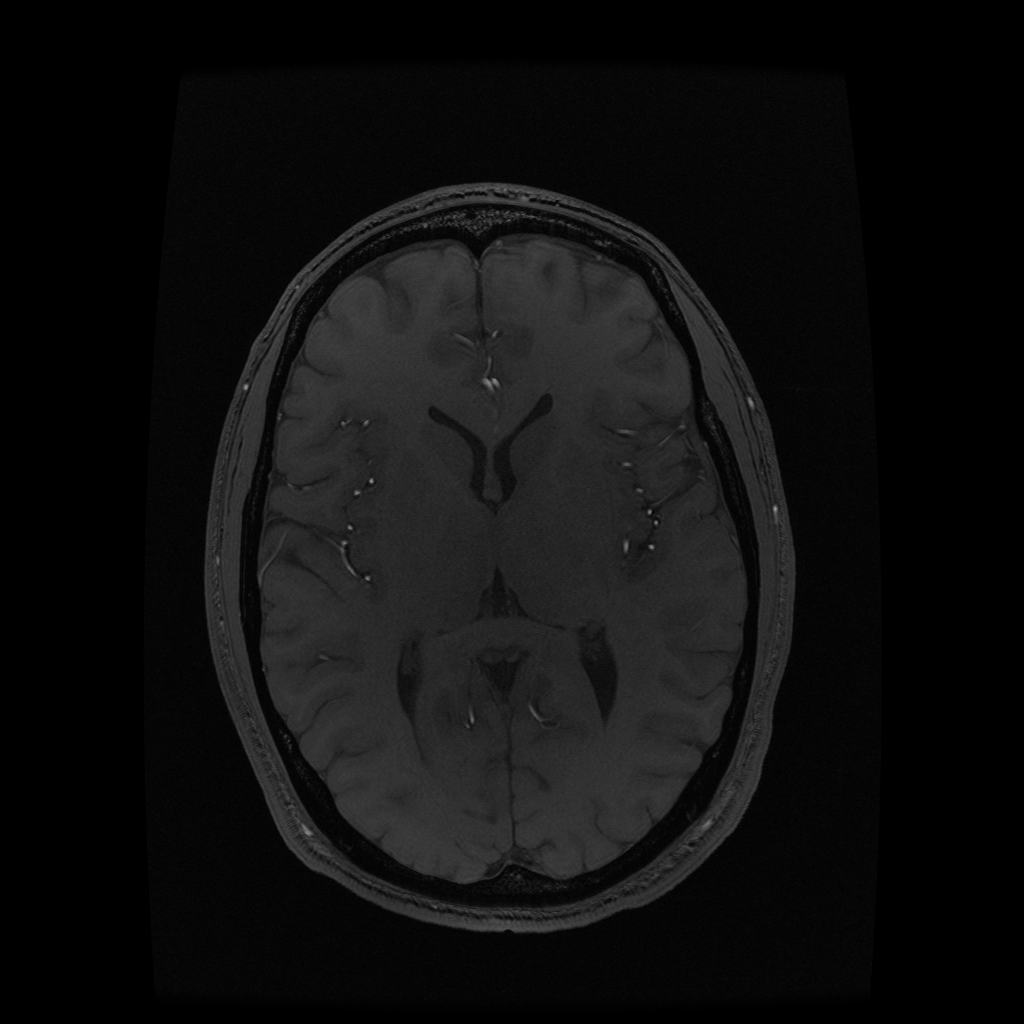

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 100   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.          0.46875     0.4687499   0.79999816  0.          0.
  0.          0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'MR'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0048001795
quatern_c       : -0.9938197
quatern_d       : -0.11078972
qoffset_x       

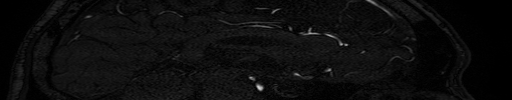

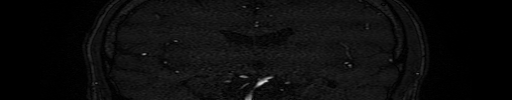

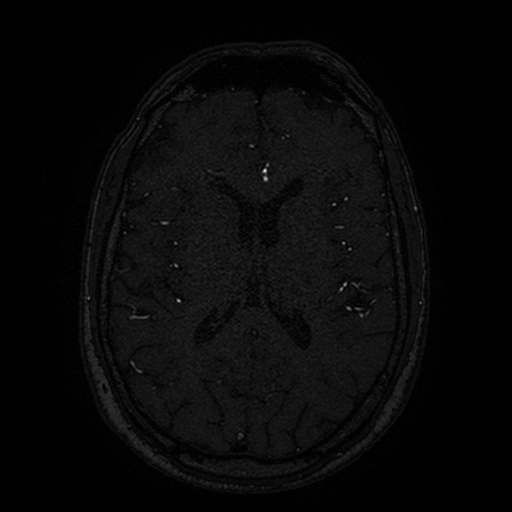

In [5]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [6]:
from utils import is_medical_volume

In total, there are

In [7]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

541

volumes. First, we discard the outliers:

In [8]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

541

We have vessel annotations for

In [9]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

len(HAVE_VESSELs)

534

of them. With a chosen ratio of 70-15-15, we select

In [10]:
COUNT_TEST = 4
COUNT_TEST

4

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [11]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

541

Finally, we randomly split our dataset. 

In [12]:
random.seed(0)

# all the HAVE_VESSELs that have imagesTs in their path
TEST_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if "imagesTs" in img]
print("test: ", [os.path.basename(img) for img in TEST_IMGs])


random.seed(1)
# COUNT_TEST random HAVE_VESSELs that are not in TEST_IMGs
VAL_IMGs = random.sample([img for img in HAVE_VESSELs if img not in TEST_IMGs], COUNT_TEST)
print("val: ")
for img in VAL_IMGs:
    print(img)

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]
print("train: ")
for img in TRAIN_IMGs:
    print(img)

f"Len train: {len(TRAIN_IMGs)}, Len val: {len(VAL_IMGs)}, Len test: {len(TEST_IMGs)}"

test:  ['IXI022-Guys-0701-MRA.nii.gz', 'IXI026-Guys-0696-MRA.nii.gz', 'IXI027-Guys-0710-MRA.nii.gz', 'IXI029-Guys-0829-MRA.nii.gz', 'IXI030-Guys-0708-MRA.nii.gz', 'IXI031-Guys-0797-MRA.nii.gz', 'IXI033-HH-1259-MRA.nii.gz', 'IXI034-HH-1260-MRA.nii.gz', 'IXI035-IOP-0873-MRA.nii.gz', 'IXI036-Guys-0736-MRA.nii.gz', 'IXI037-Guys-0704-MRA.nii.gz', 'IXI038-Guys-0729-MRA.nii.gz', 'IXI039-HH-1261-MRA.nii.gz', 'IXI041-Guys-0706-MRA.nii.gz', 'IXI045-Guys-0713-MRA.nii.gz', 'IXI046-Guys-0824-MRA.nii.gz', 'IXI048-HH-1326-MRA.nii.gz', 'IXI049-HH-1358-MRA.nii.gz', 'IXI050-Guys-0711-MRA.nii.gz', 'IXI051-HH-1328-MRA.nii.gz', 'IXI052-HH-1343-MRA.nii.gz', 'IXI053-Guys-0727-MRA.nii.gz', 'IXI054-Guys-0707-MRA.nii.gz', 'IXI055-Guys-0730-MRA.nii.gz', 'IXI056-HH-1327-MRA.nii.gz', 'IXI057-HH-1342-MRA.nii.gz', 'IXI058-Guys-0726-MRA.nii.gz', 'IXI059-HH-1284-MRA.nii.gz', 'IXI060-Guys-0709-MRA.nii.gz', 'IXI061-Guys-0715-MRA.nii.gz', 'IXI062-Guys-0740-MRA.nii.gz', 'IXI063-Guys-0742-MRA.nii.gz', 'IXI064-Guys-0743-MRA

'Len train: 18, Len val: 4, Len test: 519'

In [13]:
import pickle


with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [14]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [15]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [16]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [17]:
try:
    display_info(info["train"], info["val"])
except Exception as e:
     display_info(info["train"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,18,1776,[000.47 000.47 000.80],[000.26 000.26 000.80] - [000.47 000.47 000.80],[364.00 487.00 100.00],[321.00 433.00 092.00] - [653.00 870.00 100.00]
VAL,4,400,[000.47 000.47 000.80],[000.47 000.47 000.80] - [000.47 000.47 000.80],[355.00 492.50 100.00],[337.00 478.00 100.00] - [408.00 512.00 100.00]


In [18]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.46875   , 0.46875   , 0.79999992])

In [19]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [20]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [21]:
import os
import numpy as np

from utils import print_bold, preprocessing_loop_256

In [22]:
SPACING = np.array([0.46875   , 0.46875   , 0.79999992])

In [23]:
print_bold("Validation")
preprocessing_loop_256(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape=[256, 256]
)

Validation


  0%|          | 0/4 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.4687499  0.79999816]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.79999983), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.79999983), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


 25%|██▌       | 1/4 [00:05<00:15,  5.27s/it]

Slices processed: 256
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46874994 0.4687499  0.799995  ]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875018, 0.79999954), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750036, 0.79999954), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


...

Slices processed: 512
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.80000013]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.9375, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


 75%|███████▌  | 3/4 [00:15<00:05,  5.26s/it]

Slices processed: 768
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.7999999]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


100%|██████████| 4/4 [00:20<00:00,  5.22s/it]

Slices processed: 1024


In [24]:
print_bold("Training")
preprocessing_loop_256(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
    
)

Training


  0%|          | 0/18 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.7999998]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


  6%|▌         | 1/18 [00:05<01:29,  5.24s/it]

Slices processed: 256
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.79999995]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.9375, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


...

Slices processed: 4096
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.80000013]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


 94%|█████████▍| 17/18 [01:36<00:06,  6.01s/it]

Slices processed: 4352
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875024 0.46875003 0.80000025]

=== Resampled ===
Image - Spacing: (0.46875, 0.46874997, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.9375, 0.93749994, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


100%|██████████| 18/18 [01:42<00:00,  5.68s/it]

Slices processed: 4608


In [25]:
print_bold("Testing")
preprocessing_loop_256(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
)

Testing


  0%|          | 0/519 [00:00<?, ?it/s]

(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.4687501  0.46874985 0.80000025]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46874994, 0.8), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.9374999, 0.8), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


  0%|          | 1/519 [00:05<44:08,  5.11s/it]

Slices processed: 256
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875    0.46875    0.80000025]

=== Resampled ===
Image - Spacing: (0.46875003, 0.46875003, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.93750006, 0.93750006, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


...

Slices processed: 132352
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.8000001]

=== Resampled ===
Image - Spacing: (0.46875, 0.46875003, 0.7999999), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.9375, 0.93750006, 0.7999999), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


100%|█████████▉| 518/519 [50:46<00:05,  5.39s/it]

Slices processed: 132608
(512, 512, 100)
Target spacing: [0.46875    0.46875    0.79999992]
Current spacing: [0.46875   0.46875   0.7999997]

=== Resampled ===
Image - Spacing: (0.46875, 0.46875003, 0.79999995), Shape: (512, 512, 100)
Mask  - Shape: (512, 512, 100)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.9375, 0.93750006, 0.79999995), Shape: (256, 256, 100)
Mask  - Shape: (256, 256, 100)
Shape verification: OK


100%|██████████| 519/519 [50:51<00:00,  5.88s/it]

Slices processed: 132864


In [26]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

In [27]:
#REMEMBER TO START FROM 0 !

In [28]:
import os
from pathlib import Path
import shutil 

def rename_dataset(DATASET_PATH_RENAMED, OUTPUT_PATH_RENAMED, counter=0):
    print(f"Starting from counter: {counter+1}")
    # DELETE OUTPUT FOLDER IF EXISTS
    if os.path.exists(OUTPUT_PATH_RENAMED):
        shutil.rmtree(OUTPUT_PATH_RENAMED)
    
    Path(OUTPUT_PATH_RENAMED).mkdir(parents=True, exist_ok=True)

    print("Number of subjects: ", len(os.listdir(DATASET_PATH_RENAMED))/3)
    os.listdir(DATASET_PATH_RENAMED)

    dict_id = {}

    for img in os.listdir(DATASET_PATH_RENAMED):
        patient_id = img.split("_")[0]
        if patient_id not in dict_id:
            counter += 1
            dict_id[patient_id] = str(counter).zfill(3)
        # copy to output folder and rename\
        print("Renaming ", img, " to ", dict_id[patient_id] + "_" + img)
        shutil.copy(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
        #os.rename(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
    return counter
tr_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "train"), os.path.join(OUT_DIR, "numpy_renamed", "train"), -1)
vl_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "val"), os.path.join(OUT_DIR, "numpy_renamed", "val"), tr_counter)
rename_dataset(os.path.join(OUT_DIR, "numpy", "test"), os.path.join(OUT_DIR, "numpy_renamed", "test"), vl_counter)

Starting from counter: 0
Number of subjects:  18.0
Renaming  IXI002-Guys-0828-MRA_ToF.nii.gz  to  000_IXI002-Guys-0828-MRA_ToF.nii.gz
Renaming  IXI002-Guys-0828-MRA_brain_mask.nii.gz  to  000_IXI002-Guys-0828-MRA_brain_mask.nii.gz
Renaming  IXI002-Guys-0828-MRA_vessel.nii.gz  to  000_IXI002-Guys-0828-MRA_vessel.nii.gz
Renaming  IXI012-HH-1211-MRA_ToF.nii.gz  to  001_IXI012-HH-1211-MRA_ToF.nii.gz
Renaming  IXI012-HH-1211-MRA_brain_mask.nii.gz  to  001_IXI012-HH-1211-MRA_brain_mask.nii.gz
Renaming  IXI012-HH-1211-MRA_vessel.nii.gz  to  001_IXI012-HH-1211-MRA_vessel.nii.gz
Renaming  IXI017-Guys-0698-MRA_ToF.nii.gz  to  002_IXI017-Guys-0698-MRA_ToF.nii.gz
Renaming  IXI017-Guys-0698-MRA_brain_mask.nii.gz  to  002_IXI017-Guys-0698-MRA_brain_mask.nii.gz
Renaming  IXI017-Guys-0698-MRA_vessel.nii.gz  to  002_IXI017-Guys-0698-MRA_vessel.nii.gz
Renaming  IXI020-Guys-0700-MRA_ToF.nii.gz  to  003_IXI020-Guys-0700-MRA_ToF.nii.gz
Renaming  IXI020-Guys-0700-MRA_brain_mask.nii.gz  to  003_IXI020-Guys-0

540

In [29]:
print("All done!")

All done!
